<a href="https://colab.research.google.com/github/LuanBui1801/Vietnamese_Food_ID/blob/main/Vietnamese_food.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing import image
from PIL import Image, ImageOps, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
train_dir = "/content/drive/MyDrive/Vietnamese food"
danh_sach_mon_an = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d)) and not d.startswith('.')]
danh_sach_mon_an.sort()
datagen = ImageDataGenerator(rescale=1.0/255.0)
train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical',
    classes=danh_sach_mon_an
)
class_names = list(train_data.class_indices.keys())
print("Các món ăn tìm thấy trong tập dữ liệu:", class_names)

Found 748 images belonging to 5 classes.
Các món ăn tìm thấy trong tập dữ liệu: ['bánh mì', 'bún chả', 'cơm tấm', 'hủ tiếu', 'phở bò']


In [5]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,157 (33.42 MB)

 Trainable params: 8,761,157 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
epochs = 25
history = model.fit(train_data, epochs=epochs)
model.save("Model_Vietnamese_Food.h5")

Epoch 1/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 197s 8s/step - accuracy: 0.3810 - loss: 1.4784
Epoch 2/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 446ms/step - accuracy: 0.4853 - loss: 1.2879
Epoch 3/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 456ms/step - accuracy: 0.5909 - loss: 1.0517
Epoch 4/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 411ms/step - accuracy: 0.7340 - loss: 0.7633
Epoch 5/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 445ms/step - accuracy: 0.8690 - loss: 0.4107
Epoch 6/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 447ms/step - accuracy: 0.9492 - loss: 0.1932
Epoch 7/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 437ms/step - accuracy: 0.9813 - loss: 0.0915
Epoch 8/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 447ms/step - accuracy: 0.9853 - loss: 0.0541
Epoch 9/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 435ms/step - accuracy: 0.9920 - loss: 0.0334
Epoch 10/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 374ms/step - accuracy: 0.9947 - loss: 0.0195
Epoch 11/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 431ms/step - accuracy: 0.9933 - loss: 0.0146
Epoch 12/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 

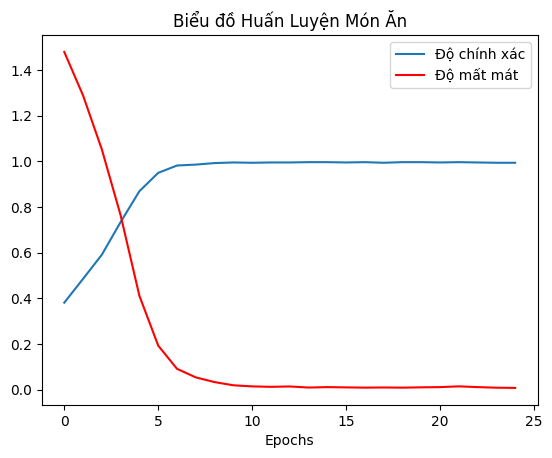

In [8]:
plt.plot(history.history['accuracy'], label='Độ chính xác')
plt.plot(history.history['loss'], label='Độ mất mát', color='red')
plt.title('Biểu đồ Huấn Luyện Món Ăn')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step


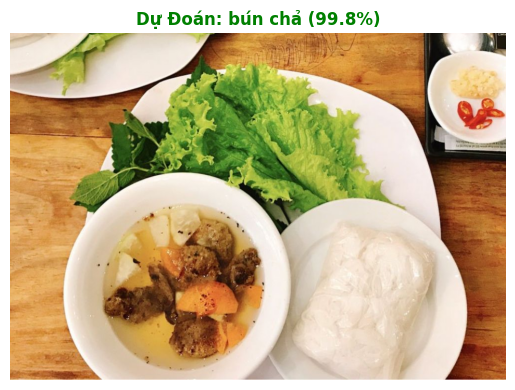

In [10]:
test_image_path = "/content/drive/MyDrive/Vietnamese food/bún chả/40f46d34-bun-cha-ha-noi-o-tphcm-2-min.jpg"
labels = train_data.class_indices
class_names_dict = {v: k for k, v in labels.items()}
try:
    model_test = load_model("Model_Vietnamese_Food.h5")
    img_raw = Image.open(test_image_path)
    img_for_display = ImageOps.exif_transpose(img_raw)
    img_rgb = img_for_display.convert("RGB")
    img_resized = img_rgb.resize((200, 200))
    img_array = image.img_to_array(img_resized)
    img_input = np.expand_dims(img_array / 255.0, axis=0)
    predictions = model_test.predict(img_input)[0]
    class_idx = np.argmax(predictions)
    confidence = predictions[class_idx] * 100
    predicted_name = class_names_dict[class_idx]
    plt.imshow(img_rgb)
    plt.title(f"Dự Đoán: {predicted_name} ({confidence:.1f}%)", color='green', fontweight='bold')
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"⚠️ Có lỗi xảy ra khi test ảnh: {e}")
    print("Mẹo: Hãy kiểm tra chắc chắn xem biến 'test_image_path' đã ghi chính xác đường dẫn ảnh chưa.")